## Task 1.3: Implementación de métricas de red en Python


Las tres funciones desarrolladas son:
1. **`grado(A)`**: Suma los valores de cada fila de la matriz para determinar la cantidad de conexiones de cada nodo.
2. **`clustering(A)`**: Identifica los vecinos de cada nodo y calcula la proporción entre las conexiones existentes entre ellos y las conexiones posibles totales. Si un nodo tiene menos de dos vecinos, su coeficiente es 0.
3. **`distancia_promedio(A)`**: Implementa el algoritmo de Búsqueda en Anchura (BFS) para encontrar la distancia geodésica entre todos los pares de nodos. Únicamente toma en cuenta pares únicos (sin contar la distancia de un nodo a sí mismo ni contar pares duplicados) y excluye nodos desconectados del cálculo del promedio.

In [4]:
import numpy as np
from collections import deque

def grado(A):
    """
    Calcula el grado de cada nodo en la red.
    """
    # Diapositiva 4: el grado k_i representa el número de aristas conectadas al nodo i.
    return np.sum(A, axis=1)

def clustering(A):
    """
    Calcula el coeficiente de clustering local para cada nodo.
    """
    # Diapositiva 5: el coeficiente de clustering mide la fracción de pares de vecinos conectados entre sí.
    n = A.shape[0]
    C = np.zeros(n)
    
    for i in range(n):
        # Encontrar los vecinos del nodo i (índices donde hay un 1)
        vecinos = np.where(A[i] == 1)[0]
        k_i = len(vecinos)
        
        # Si tiene menos de 2 vecinos, no puede haber conexiones entre ellos
        if k_i < 2:
            C[i] = 0.0
        else:
            aristas_posibles = (k_i * (k_i - 1)) / 2
            aristas_reales = 0
            
            # Contar conexiones reales entre los vecinos
            for x in range(k_i):
                for y in range(x + 1, k_i):
                    if A[vecinos[x], vecinos[y]] == 1:
                        aristas_reales += 1
                        
            C[i] = aristas_reales / aristas_posibles
            
    return C

def distancia_promedio(A):
    """
    Calcula la distancia geodésica promedio utilizando BFS.
    Solo promedia sobre los pares de nodos que tienen un camino.
    """
    # Diapositiva 5: la distancia promedio corresponde al número medio de aristas en los caminos más cortos.
    n = A.shape[0]
    distancias = []
    
    for nodo_inicio in range(n):
        # Diccionario para almacenar las distancias desde el nodo_inicio
        visitados = {nodo_inicio: 0}
        cola = deque([nodo_inicio])
        
        # BFS para encontrar los caminos más cortos
        # Diapositiva 5: BFS permite encontrar los caminos más cortos entre pares de nodos.
        while cola:
            actual = cola.popleft()
            vecinos = np.where(A[actual] == 1)[0]
            
            for vecino in vecinos:
                if vecino not in visitados:
                    visitados[vecino] = visitados[actual] + 1
                    cola.append(vecino)
        
        # Guardar las distancias solo para nodos con índice mayor (evita duplicados y distancia a sí mismo)
        for j in range(nodo_inicio + 1, n):
            if j in visitados:
                distancias.append(visitados[j])
                
    if not distancias:
        return 0.0
        
    return sum(distancias) / len(distancias)


# ==========================================
# Verificación con la Matriz del Task 1.2
# ==========================================

# Matriz de adyacencia proporcionada en el Task 1.2
A_task1_2 = np.array([
    [0, 1, 1, 0, 0],
    [1, 0, 1, 1, 0],
    [1, 1, 0, 0, 1],
    [0, 1, 0, 0, 1],
    [0, 0, 1, 1, 0]
])

print("=== Verificación Task 1.3 ===")
print(f"a. Grado de cada nodo: {grado(A_task1_2)}")
print(f"b. Coeficiente de clustering de cada nodo: {np.round(clustering(A_task1_2), 3)}")
print(f"c. Distancia promedio de la red: {distancia_promedio(A_task1_2)}")

=== Verificación Task 1.3 ===
a. Grado de cada nodo: [2 3 3 2 2]
b. Coeficiente de clustering de cada nodo: [1.    0.333 0.333 0.    0.   ]
c. Distancia promedio de la red: 1.4


## Task 3.1: Generación y análisis de redes sintéticas

En esta sección se generan tres redes sintéticas utilizando la librería NetworkX con los parámetros especificados:
1. **Red aleatoria (Erdos-Rényi):** $N=500$, $p=0.02$.
2. **Red libre de escala (Barabási-Albert):** $N=500$, $m=5$.
3. **Red de mundo pequeño (Watts-Strogatz):** $N=500$, $k=6$, $p=0.1$.

Para cada red, se calculan y reportan las siguientes métricas topológicas en una tabla comparativa:
*   Grado promedio $\langle k \rangle$.
*   Segundo momento del grado $\langle k^2 \rangle$.
*   Coeficiente de clustering promedio $\langle C \rangle$.
*   Distancia promedio $\langle d \rangle$.
*   Umbral epidémico crítico $\beta/\gamma$. La fórmula utilizada para el umbral epidémico en redes heterogéneas es $\frac{\langle k \rangle}{\langle k^2 \rangle - \langle k \rangle}$.

Finalmente, se grafica la distribución de grado $P(k)$ de las tres redes en una figura con tres paneles, aplicando una escala log-log a los ejes de la red libre de escala para visualizar correctamente el comportamiento de la ley de potencias.

=== Tabla Comparativa de Métricas de Red ===


,Topología,<k>,<k^2>,<C>,<d>,Umbral (β/γ)
0,Aleatoria (Erdos-Rényi),9.748,104.216,0.016117,2.967447,0.103188
1,Libre de Escala (Barabási-Albert),9.900,203.112,0.079000,2.730846,0.051239
2,Mundo Pequeño (Watts-Strogatz),6.000,36.488,0.464452,5.697202,0.196799


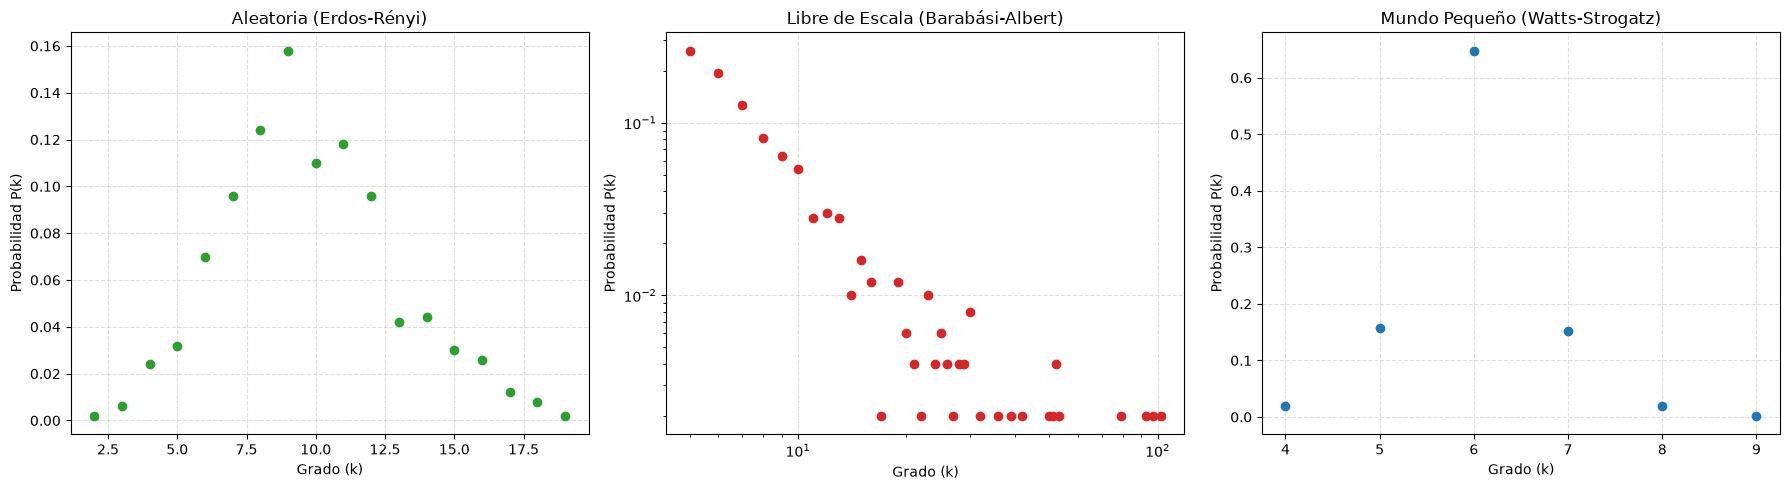

In [5]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Generación de las redes sintéticas
# Diapositiva 4: una red está formada por nodos y aristas que representan entidades y sus relaciones.
N = 500
# Diapositiva 8: Erdos-Renyi representa una red aleatoria con distribución de grado aproximadamente Poisson.
G_er = nx.erdos_renyi_graph(n=N, p=0.02, seed=42)          # Red Aleatoria
# Diapositiva 9: Barabási-Albert modela una red libre de escala con hubs dominantes y distribución tipo ley de potencias.
G_ba = nx.barabasi_albert_graph(n=N, m=5, seed=42)         # Red Libre de Escala
# Diapositiva 10: Watts-Strogatz genera una red de mundo pequeño con clustering alto y distancias cortas.
G_ws = nx.watts_strogatz_graph(n=N, k=6, p=0.1, seed=42)   # Red de Mundo Pequeño

# Función para calcular las métricas solicitadas
def calcular_metricas(G):
    # Lista de grados de todos los nodos
    # Diapositiva 4: el grado promedio <k> resume la conectividad promedio de todos los nodos.
    grados = [d for n, d in G.degree()]
    
    # <k>: Grado promedio
    k_avg = np.mean(grados)
    
    # <k^2>: Segundo momento del grado
    # Diapositiva 12: <k^2> participa en el cálculo del umbral epidémico de redes heterogéneas.
    k2_avg = np.mean(np.array(grados)**2)
    
    # <C>: Coeficiente de clustering promedio
    # Diapositiva 5: el clustering promedio permite comparar la estructura local de las topologías.
    c_avg = nx.average_clustering(G)
    
    # <d>: Distancia promedio (validando que la red sea conexa)
    # Diapositiva 5: la distancia promedio mide la longitud media de los caminos más cortos.
    if nx.is_connected(G):
        d_avg = nx.average_shortest_path_length(G)
    else:
        # Si no es conexa, se calcula sobre el componente gigante
        G_cc = G.subgraph(max(nx.connected_components(G), key=len))
        d_avg = nx.average_shortest_path_length(G_cc)
        
    # Umbral epidémico crítico: <k> / (<k^2> - <k>)
    # Se evita división por cero
    # Diapositiva 12: en redes heterogéneas el umbral es <k>/(<k^2>-<k>).
    umbral = k_avg / (k2_avg - k_avg) if (k2_avg - k_avg) > 0 else float('inf')
    
    return k_avg, k2_avg, c_avg, d_avg, umbral

# Cálculo para cada red
metricas_er = calcular_metricas(G_er)
metricas_ba = calcular_metricas(G_ba)
metricas_ws = calcular_metricas(G_ws)

# Creación y visualización de la tabla comparativa
df_metricas = pd.DataFrame({
    'Topología': ['Aleatoria (Erdos-Rényi)', 'Libre de Escala (Barabási-Albert)', 'Mundo Pequeño (Watts-Strogatz)'],
    '<k>': [metricas_er[0], metricas_ba[0], metricas_ws[0]],
    '<k^2>': [metricas_er[1], metricas_ba[1], metricas_ws[1]],
    '<C>': [metricas_er[2], metricas_ba[2], metricas_ws[2]],
    '<d>': [metricas_er[3], metricas_ba[3], metricas_ws[3]],
    'Umbral (β/γ)': [metricas_er[4], metricas_ba[4], metricas_ws[4]]
})

print("=== Tabla Comparativa de Métricas de Red ===")
display(df_metricas)

# Gráficas de la distribución de grado P(k)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_distribucion_grado(G, ax, title, usar_loglog=False, color='blue'):
    # Diapositiva 5: P(k) es la fracción de nodos que tiene exactamente k conexiones.
    grados = [d for n, d in G.degree()]
    conteo = Counter(grados)
    # Extraer valores de k y calcular la probabilidad P(k)
    k_vals = list(conteo.keys())
    pk_vals = [val / N for val in conteo.values()]

    # Diapositiva 9: la escala log-log permite observar la ley de potencias de una red libre de escala.
    if usar_loglog:
        ax.loglog(k_vals, pk_vals, marker='o', linestyle='none', color=color, markersize=6)
    else:
        ax.plot(k_vals, pk_vals, marker='o', linestyle='none', color=color, markersize=6)
        
    ax.set_title(title)
    ax.set_xlabel('Grado (k)')
    ax.set_ylabel('Probabilidad P(k)')
    ax.grid(True, alpha=0.4, linestyle='--')

# Panel 1: Red Aleatoria
plot_distribucion_grado(G_er, axes[0], 'Aleatoria (Erdos-Rényi)', usar_loglog=False, color='#2ca02c')

# Panel 2: Red Libre de Escala (escala log-log obligatoria)
plot_distribucion_grado(G_ba, axes[1], 'Libre de Escala (Barabási-Albert)', usar_loglog=True, color='#d62728')

# Panel 3: Red de Mundo Pequeño
plot_distribucion_grado(G_ws, axes[2], 'Mundo Pequeño (Watts-Strogatz)', usar_loglog=False, color='#1f77b4')

plt.tight_layout()
plt.show()

## Task 3.2: Simulación del proceso SIR en redes complejas (Incisos a y b)

En esta sección se simula la propagación de una epidemia bajo el modelo SIR (Susceptibles, Infectados, Recuperados) sobre las tres redes generadas en el Task 3.1. 

Los parámetros utilizados para la simulación son:
*   Probabilidad de transmisión por arista ($\beta$): 0.04 por paso de tiempo.
*   Probabilidad de recuperación ($\gamma$): 0.03 por paso de tiempo.
*   Condición inicial: 5 nodos infectados al azar, el resto susceptibles.
*   Número de realizaciones (simulaciones) por red: 50.

**Inciso a:** Se registra el tamaño final del brote (fracción de la población recuperada al final de la simulación) para cada una de las 50 realizaciones. Se reporta la media y el intervalo de confianza (IC) del 95% para cada topología.

**Inciso b:** Se grafican las trayectorias de la fracción de infectados $I(t)/N$ a lo largo del tiempo. Las 50 realizaciones se muestran con líneas transparentes para observar la variabilidad, y se superpone una línea gruesa que representa la trayectoria promedio del brote en cada red.

=== Resultados Task 3.2 (a) ===

--- Aleatoria (Erdos-Rényi) ---
Media del tamaño del brote: 0.9972
IC 95%: [0.9966, 0.9978]

--- Libre de Escala (Barabási-Albert) ---
Media del tamaño del brote: 0.9954
IC 95%: [0.9945, 0.9963]

--- Mundo Pequeño (Watts-Strogatz) ---
Media del tamaño del brote: 0.9852
IC 95%: [0.9817, 0.9887]



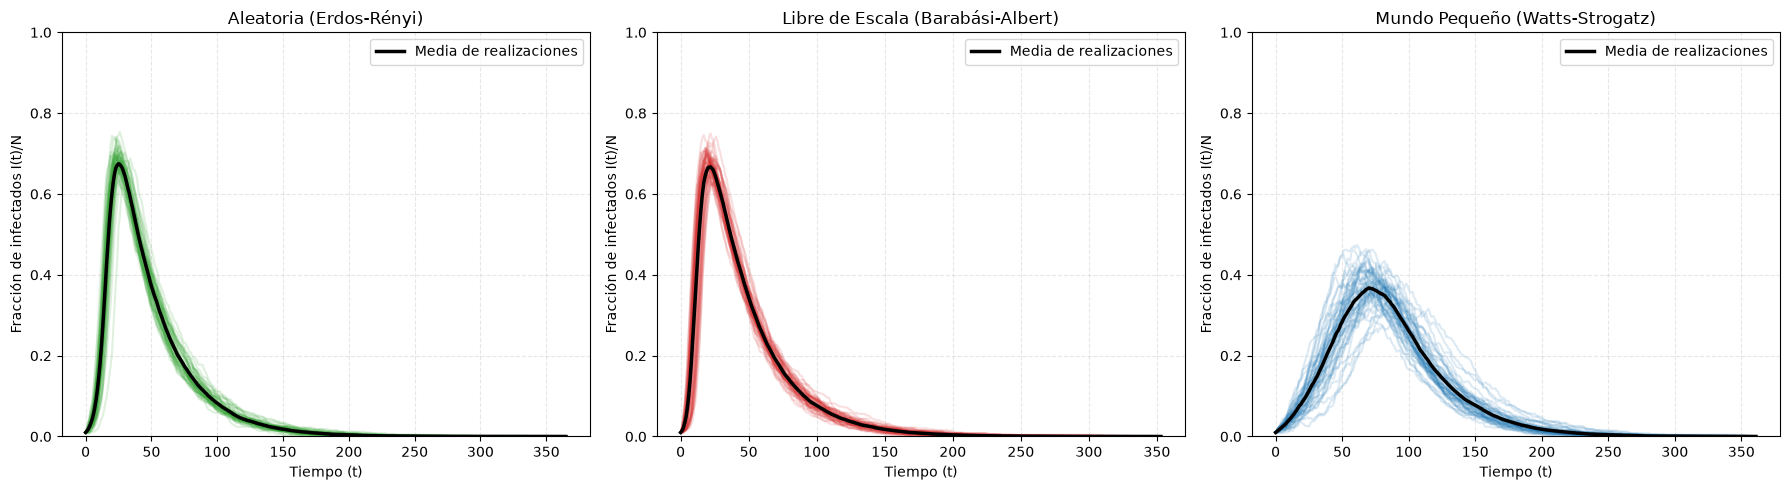

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la simulación
BETA = 0.04
GAMMA = 0.03
INITIAL_INFECTED = 5
NUM_REALIZACIONES = 50
N = 500  # Número total de nodos

def simular_SIR(G, beta, gamma, initial_infected):
    """
    Simula un proceso SIR discreto sobre una red G.
    Retorna el tamaño final del brote (fracción) y la trayectoria de I(t)/N.
    """
    # Estados: 0 = Susceptible, 1 = Infectado, 2 = Recuperado
    # Diapositiva 6: cada nodo interactúa únicamente con los agentes de su vecindario en la red.
    estados = np.zeros(N, dtype=int)
    
    # Infección inicial aleatoria
    # Diapositiva 14: la topología define qué agentes pueden transmitir la infección entre sí.
    nodos_iniciales = np.random.choice(N, initial_infected, replace=False)
    estados[nodos_iniciales] = 1
    
    # Registro de infectados en el tiempo
    I_t = [initial_infected / N]
    
    while True:
        infectados_actuales = np.where(estados == 1)[0]
        
        # Condición de paro: ya no hay infectados
        if len(infectados_actuales) == 0:
            break
            
        nuevos_estados = estados.copy()
        
        # 1. Proceso de transmisión
        # Diapositiva 12: el modelo SIR utiliza transmisión beta y recuperación gamma.
        for u in infectados_actuales:
            vecinos = list(G.neighbors(u))
            # Diapositiva 6: la transmisión ocurre solo entre nodos vecinos conectados por una arista.
            vecinos_susceptibles = [v for v in vecinos if estados[v] == 0]
            for v in vecinos_susceptibles:
                if np.random.rand() < beta:
                    nuevos_estados[v] = 1
                    
        # 2. Proceso de recuperación
        # Diapositiva 12: la relación beta/gamma determina la capacidad de propagación epidémica.
        for u in infectados_actuales:
            if np.random.rand() < gamma:
                nuevos_estados[u] = 2
                
        # Actualización de estados
        estados = nuevos_estados
        I_t.append(np.sum(estados == 1) / N)
        
    # Tamaño final del brote (fracción de la población en estado Recuperado)
    # Diapositiva 3: el tamaño final permite analizar cómo la topología afecta el alcance del contagio.
    tamanio_final = np.sum(estados == 2) / N
    return tamanio_final, I_t

def ejecutar_ensamble(G, nombre_red, beta, gamma, initial_infected, num_realizaciones):
    """Ejecuta múltiples realizaciones y recolecta estadísticas y trayectorias."""
    tamanios = []
    trayectorias = []
    
    for _ in range(num_realizaciones):
        tamanio, I_t = simular_SIR(G, beta, gamma, initial_infected)
        tamanios.append(tamanio)
        trayectorias.append(I_t)
        
    # Calcular Media e Intervalo de Confianza (95%)
    media = np.mean(tamanios)
    std = np.std(tamanios, ddof=1)
    ic_95 = 1.96 * (std / np.sqrt(num_realizaciones))
    
    print(f"--- {nombre_red} ---")
    print(f"Media del tamaño del brote: {media:.4f}")
    print(f"IC 95%: [{media - ic_95:.4f}, {media + ic_95:.4f}]\n")
    
    return tamanios, trayectorias

# ==========================================
# Task 3.2 a: Ejecución y reporte de métricas
# ==========================================
print("=== Resultados Task 3.2 (a) ===\n")
# Diapositiva 16: una misma dinámica de contagio puede producir resultados distintos según la topología de la red.
tamanios_er, trayectorias_er = ejecutar_ensamble(G_er, "Aleatoria (Erdos-Rényi)", BETA, GAMMA, INITIAL_INFECTED, NUM_REALIZACIONES)
tamanios_ba, trayectorias_ba = ejecutar_ensamble(G_ba, "Libre de Escala (Barabási-Albert)", BETA, GAMMA, INITIAL_INFECTED, NUM_REALIZACIONES)
tamanios_ws, trayectorias_ws = ejecutar_ensamble(G_ws, "Mundo Pequeño (Watts-Strogatz)", BETA, GAMMA, INITIAL_INFECTED, NUM_REALIZACIONES)

# ==========================================
# Task 3.2 b: Graficación de las trayectorias
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def graficar_trayectorias(trayectorias, ax, titulo, color):
    # Encontrar la longitud máxima para poder promediar los arrays de distinto tamaño
    max_len = max(len(t) for t in trayectorias)
    matriz_trayectorias = np.zeros((NUM_REALIZACIONES, max_len))
    
    for i, t in enumerate(trayectorias):
        # Graficar cada realización con transparencia
        ax.plot(range(len(t)), t, color=color, alpha=0.15)
        # Llenar la matriz (el resto se queda en 0, que es correcto porque ya no hay infectados)
        matriz_trayectorias[i, :len(t)] = t
        
    # Calcular y graficar la media en cada instante de tiempo (línea gruesa)
    media_trayectoria = np.mean(matriz_trayectorias, axis=0)
    ax.plot(range(max_len), media_trayectoria, color='black', linewidth=2.5, label='Media de realizaciones')
    
    ax.set_title(titulo)
    ax.set_xlabel('Tiempo (t)')
    ax.set_ylabel('Fracción de infectados I(t)/N')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 1.0) # Normalizar el eje Y para que todas las gráficas sean visualmente comparables
    ax.legend(loc='upper right')

# Generar paneles
graficar_trayectorias(trayectorias_er, axes[0], 'Aleatoria (Erdos-Rényi)', '#2ca02c')
graficar_trayectorias(trayectorias_ba, axes[1], 'Libre de Escala (Barabási-Albert)', '#d62728')
graficar_trayectorias(trayectorias_ws, axes[2], 'Mundo Pequeño (Watts-Strogatz)', '#1f77b4')

plt.tight_layout()
plt.show()